# Customer Churn Prediction & LTV Engine

## Baseline Analytics Report — Day 1

### Prepared by: Akshay

This notebook contains the baseline customer metrics and initial
visual analysis for the Customer Churn Prediction & LTV Engine project.

### Objectives
- Calculate basic customer metrics
- Calculate customer churn percentage
- Understand basic customer characteristics
- Suggest charts for the final dashboard

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn (1).csv.xlsx")

## Data Preparation — TotalCharges

The TotalCharges column was initially stored as an object/string data type.
It was converted to numeric using pd.to_numeric() with errors="coerce".
The 11 resulting missing values correspond to customers with zero tenure,
so they were replaced with 0.

In [24]:
# Convert TotalCharges from object/string to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Handle missing TotalCharges values
# Customers with zero tenure have no accumulated total charges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [25]:
print("TotalCharges data type:", df["TotalCharges"].dtype)
print("Missing TotalCharges values:", df["TotalCharges"].isna().sum())

TotalCharges data type: float64
Missing TotalCharges values: 0


In [26]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [27]:
df["TotalCharges"].dtype

dtype('float64')

## TotalCharges Data Type Correction

The TotalCharges column was initially stored as an object/string data type.
It was converted to numeric using pd.to_numeric() with errors="coerce".
The 11 resulting missing values correspond to customers with zero tenure,
so they were replaced with 0.

In [28]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [29]:
df["TotalCharges"].dtype

dtype('float64')

In [30]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [31]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [32]:
# Handle missing TotalCharges values
# Customers with zero tenure have no accumulated total charges
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [33]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [34]:
df["TotalCharges"].dtype

dtype('float64')

In [35]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [4]:
df.shape

(7043, 21)

In [37]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [39]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [40]:
df[["tenure", "MonthlyCharges"]].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


In [41]:
# Baseline Customer KPIs

total_customers = df.shape[0]
churned_customers = (df["Churn"] == "Yes").sum()
churn_rate = (churned_customers / total_customers) * 100
average_tenure = df["tenure"].mean()
average_monthly_charges = df["MonthlyCharges"].mean()

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("Average Tenure:", round(average_tenure, 2), "months")
print("Average Monthly Charges:", round(average_monthly_charges, 2))

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Tenure: 32.37 months
Average Monthly Charges: 64.76


## 1. Baseline Customer KPIs

The following metrics provide an initial overview of the customer
base and the current churn situation.

In [42]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Churn Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        round(churn_rate, 2),
        round(average_tenure, 2),
        round(average_monthly_charges, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Customers,7043.00
1,Churned Customers,1869.00
2,Churn Rate (%),26.54
3,Average Tenure (Months),32.37
4,Average Monthly Charges,64.76


### Key Findings

- The dataset contains 7,043 customers.
- 1,869 customers have churned.
- The overall churn rate is 26.54%.
- Average customer tenure is 32.37 months.
- Average monthly charge is 64.76.

## 2. Customer Churn Distribution

This chart compares customers who stayed with the company against
customers who churned.

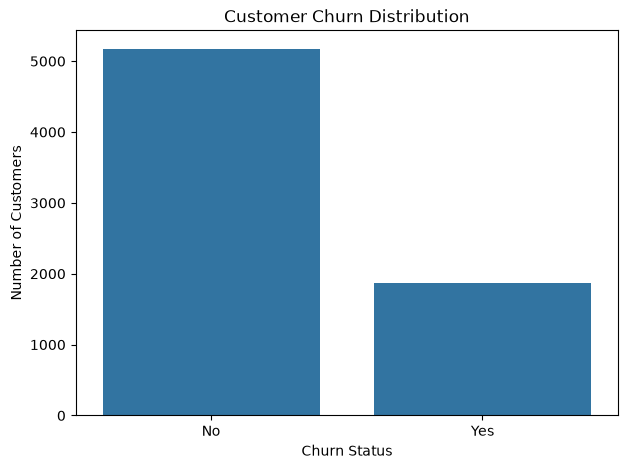

In [43]:
# Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=churn_counts.index, y=churn_counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding

The dataset contains 5,174 customers who did not churn and
1,869 customers who churned. The overall churn rate is 26.54%.

## 3. Churn Rate by Contract Type

This analysis compares the percentage of customers who churn
across different contract types.

In [44]:
# Churn by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Finding

Month-to-month contract customers have the highest churn rate,
while two-year contract customers have the lowest churn rate.

This indicates that contract type is strongly associated with
customer churn in this dataset.

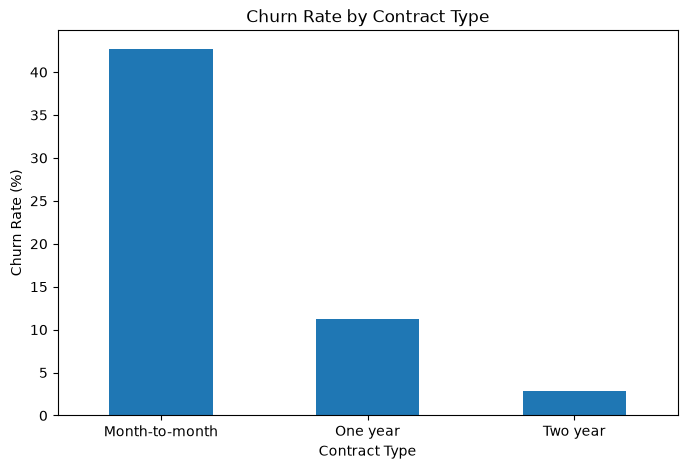

In [45]:
# Visualize churn rate by contract type

contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 4. Dashboard Recommendations

Based on the baseline analysis, the following elements are recommended
for the final customer churn dashboard.

### KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Recommended Charts

1. Customer Churn Distribution
2. Churn Rate by Contract Type
3. Churn Rate by Internet Service
4. Churn Rate by Payment Method
5. Churn Rate by Tenure

### Dashboard Purpose

The dashboard should provide a simple overview of the customer base,
highlight the current churn situation, and help stakeholders identify
customer segments that may require further investigation.

The final dashboard design and additional charts should be confirmed
with the team before implementation.

## 5. Conclusion

The baseline analysis provides an initial understanding of the
customer population and churn situation.

The dataset contains 7,043 customers, of which 1,869 have churned,
resulting in an overall churn rate of 26.54%.

The average customer tenure is 32.37 months and the average monthly
charge is 64.76.

The initial visual analysis also shows a clear difference in churn
rates across contract types, with month-to-month customers showing
the highest churn rate.

These results provide the baseline information required for the
next stages of the Customer Churn Prediction & LTV Engine project.

# Customer Churn Dashboard Draft — Day 2

## Dashboard Overview

This section presents the initial dashboard draft based on the
baseline customer churn analysis completed on Day 1.

The dashboard is designed to provide a quick overview of customer
volume, churn status, customer tenure, and monthly charges.

## 1. Key Performance Indicators (KPIs)

The following KPIs provide a quick summary of the customer base and
the current churn situation.

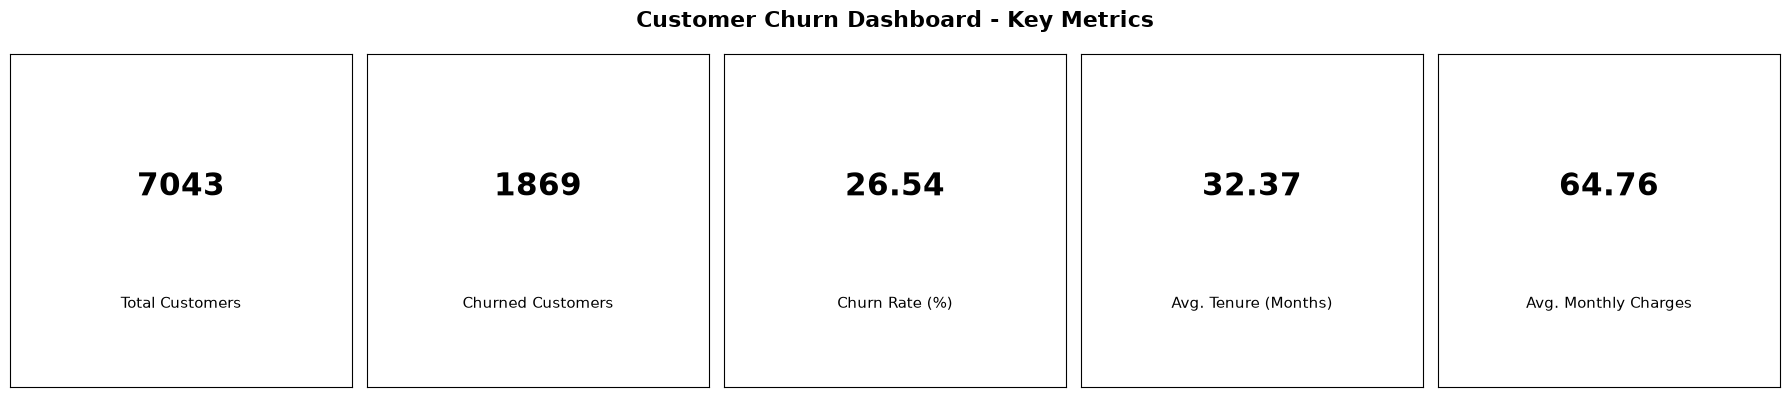

In [46]:
# Day 2 - Dashboard KPI Cards

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

kpis = [
    ("Total Customers", total_customers),
    ("Churned Customers", churned_customers),
    ("Churn Rate (%)", round(churn_rate, 2)),
    ("Avg. Tenure (Months)", round(average_tenure, 2)),
    ("Avg. Monthly Charges", round(average_monthly_charges, 2))
]

for ax, (title, value) in zip(axes, kpis):
    ax.text(
        0.5, 0.6, str(value),
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    
    ax.text(
        0.5, 0.25, title,
        ha="center",
        va="center",
        fontsize=11
    )
    
    ax.set_xticks([])
    ax.set_yticks([])
    
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle("Customer Churn Dashboard - Key Metrics",
             fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### KPI Summary

The customer base contains 7,043 customers, with 1,869 customers
having churned. The overall churn rate is 26.54%.

The average customer tenure is 32.37 months, while the average
monthly charge is 64.76.

These KPIs provide a high-level view of the customer base and will
serve as the primary summary metrics for the final dashboard.

## 2. Customer Churn Distribution

This chart shows the number of customers who have churned compared
with customers who have remained with the company.

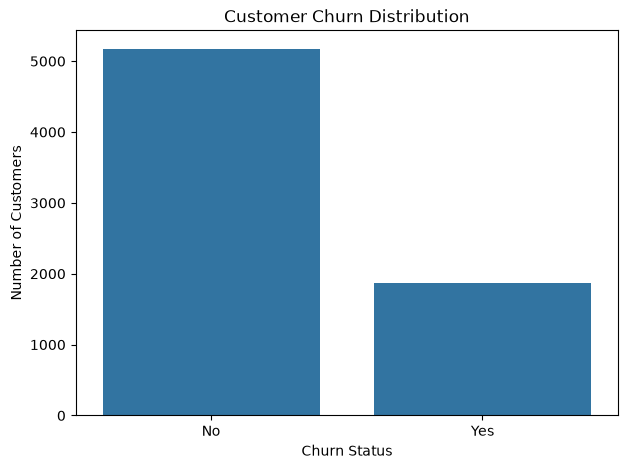

In [47]:
# Dashboard Chart 1 - Customer Churn Distribution

churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Finding

The dataset contains more customers who stayed with the company than
customers who churned. However, 1,869 customers have churned,
representing an overall churn rate of 26.54%.

This chart provides a simple overview of the current customer churn
situation.

## 3. Churn Rate by Contract Type

This chart compares the percentage of customers who churn across
different contract types.

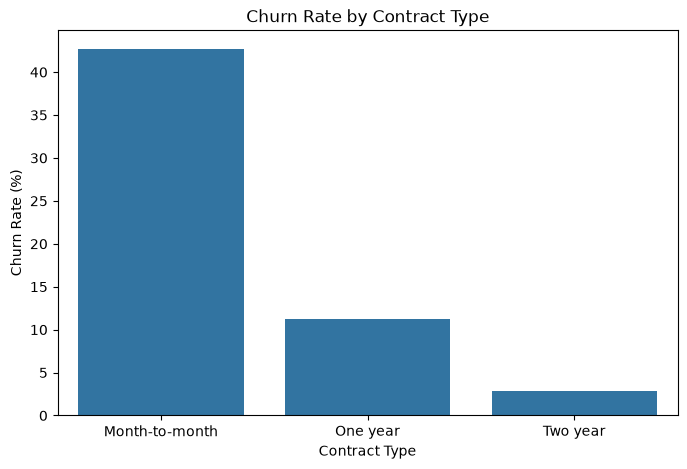

In [48]:
# Dashboard Chart 2 - Churn Rate by Contract Type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=contract_churn.index,
    y=contract_churn["Yes"]
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

### Finding

Month-to-month contract customers have the highest churn rate,
while two-year contract customers have the lowest churn rate.

This indicates a clear difference in churn rates across contract
types and makes contract type an important segment to consider
in the final dashboard.

## 4. Dashboard Components

Based on the baseline analysis, the initial dashboard should contain
the following components:

### KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Main Charts

- Customer Churn Distribution
- Churn Rate by Contract Type

### Future Dashboard Charts

The following charts can be added after the detailed customer and
service-level analysis is completed:

- Churn Rate by Internet Service
- Churn Rate by Payment Method
- Churn Rate by Tenure

The final dashboard should be updated using the cleaned and
team-approved dataset.

## 5. Proposed Dashboard Layout

The proposed dashboard layout is organized to provide a quick and
clear view of customer churn.

### Top Section — KPI Cards

- Total Customers
- Churned Customers
- Churn Rate
- Average Tenure
- Average Monthly Charges

### Middle Section — Churn Analysis

- Customer Churn Distribution
- Churn Rate by Contract Type

### Lower Section — Detailed Analysis

- Churn Rate by Internet Service
- Churn Rate by Payment Method
- Churn Rate by Tenure

### Dashboard Objective

The dashboard is intended to help stakeholders quickly understand
the overall churn situation and identify customer segments that may
require further investigation.

The final dashboard will be updated after the cleaned and
team-approved dataset is available.

## 6. Day 2 Conclusion

The initial customer churn dashboard draft has been prepared using
the baseline analysis from Day 1.

The dashboard currently includes key customer KPIs, customer churn
distribution, and churn rate by contract type.

Additional charts will be incorporated after the detailed customer
and service-level analysis is completed and the cleaned dataset is
approved by the team.

In [49]:
df["TotalCharges"].dtype

dtype('float64')

In [50]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].dtype

dtype('float64')

In [51]:
df["TotalCharges"].isna().sum()

np.int64(0)

# Day 3 — Detailed Data Cleaning & Exploratory Data Analysis (EDA)

## Objective

The objective of Day 3 is to examine the quality and structure of the
customer churn dataset and identify important customer and service
characteristics associated with customer churn.

The analysis will include data quality checks, numerical and
categorical variable analysis, and churn analysis across important
customer segments.

## 1. Data Quality Check

Before performing detailed exploratory analysis, the dataset is
checked for its dimensions, columns, data types, missing values,
and duplicate records.

In [52]:
# Check number of rows and columns
df.shape

(7043, 21)

In [53]:
# Display all column names
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [54]:
# Check data types of all columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [55]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [56]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## 2. Numerical Variable Analysis

The numerical variables are analyzed using descriptive statistics to understand their central tendency, spread, and range.

In [57]:
# Descriptive statistics for numerical variables
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


### 2.1 Customer Tenure Distribution

The distribution of customer tenure is visualized to understand how long customers have been associated with the company.

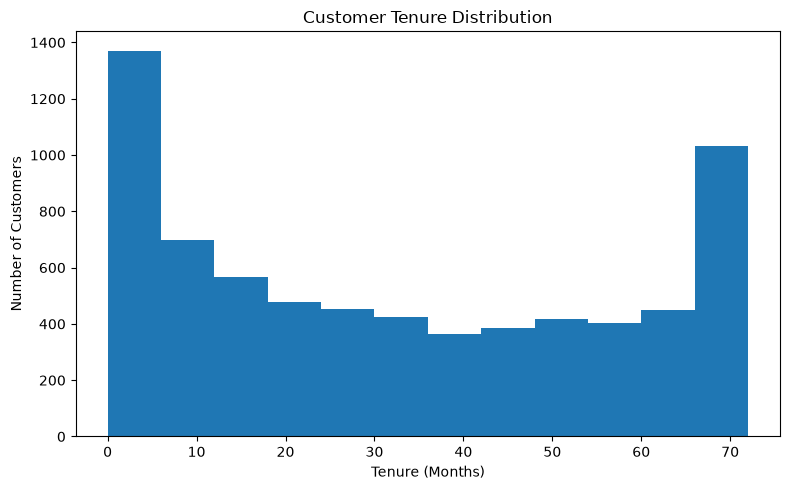

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["tenure"], bins=12)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The tenure distribution shows a high concentration of customers with very low tenure, particularly during the first few months. A second noticeable concentration is observed among customers with longer tenure near 60–72 months. This indicates that the customer base contains both newer and long-term customers, making tenure an important variable for further churn analysis.

### 2.2 Monthly Charges Distribution

The distribution of monthly charges is visualized to understand the range and concentration of customer monthly billing.

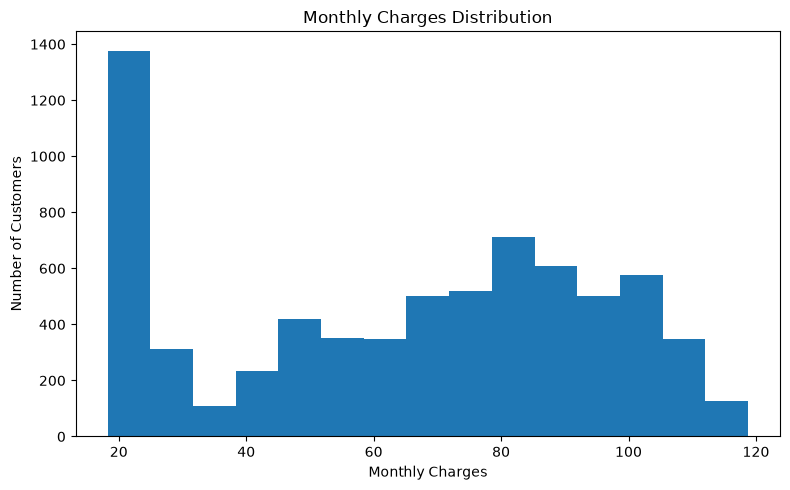

In [59]:
plt.figure(figsize=(8, 5))

plt.hist(df["MonthlyCharges"], bins=15)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The monthly charges distribution shows a high concentration of customers in the lower monthly-charge range, particularly around 18–30. Customer counts are more distributed across the higher charge ranges, with noticeable concentrations around 70–105. This variation in monthly charges makes it an important variable for further customer churn analysis.

### 2.3 Total Charges Distribution

The distribution of total charges is visualized to understand the accumulated charges paid by customers and identify the overall spread of customer spending.

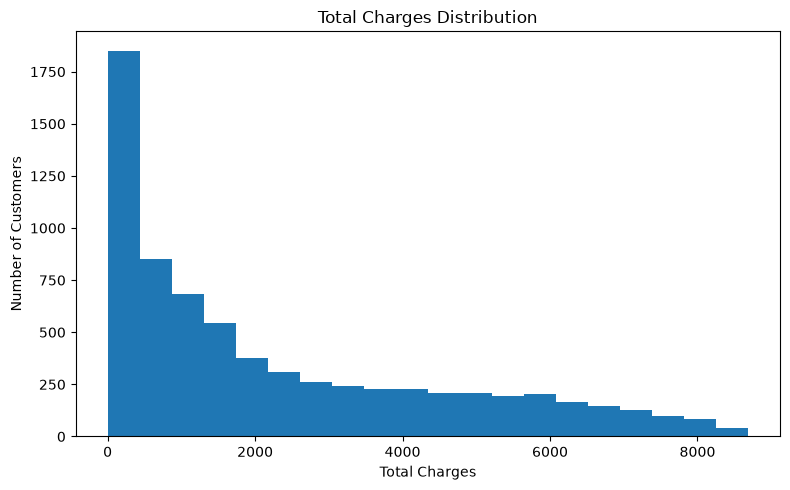

In [60]:
plt.figure(figsize=(8, 5))

plt.hist(df["TotalCharges"], bins=20)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Finding

The TotalCharges distribution is strongly concentrated toward lower total charge values, with the number of customers gradually decreasing as total charges increase. A smaller proportion of customers have high accumulated charges. This pattern is influenced by customer tenure because customers who have stayed longer with the company generally have more accumulated charges.

## 3. Categorical Variable Analysis

Categorical variables are analyzed to understand the distribution of customers across different groups and identify segments that may show differences in churn behavior.

In [61]:
# Check the number of customers in each contract type
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

### Finding

Month-to-month contracts represent the largest customer segment with 3,875 customers, followed by two-year contracts with 1,695 customers and one-year contracts with 1,473 customers. Since month-to-month customers also showed the highest churn rate in the earlier analysis, contract type is an important segment for further churn investigation.

In [62]:
# Check the number of customers in each internet service type
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

### Finding

Fiber optic customers represent the largest Internet Service segment with 3,096 customers, followed by DSL customers with 2,421 customers. A total of 1,526 customers have no internet service. Internet Service is therefore an important customer characteristic to consider when analyzing churn behavior.

In [63]:
# Check the number of customers using each payment method
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

### Finding

Electronic check is the most commonly used payment method, with 2,365 customers. Mailed check is used by 1,612 customers, while automatic bank transfer and automatic credit card payments are used by 1,544 and 1,522 customers, respectively. Payment method will be examined further to determine whether customer churn differs across these groups.

In [64]:
# Check the number of customers by churn status
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Finding

The dataset contains 5,174 customers who have not churned and 1,869 customers who have churned. Churned customers represent 26.54% of the total customer base. This confirms that a significant proportion of customers have left the company and makes churn analysis important for identifying high-risk customer segments.


## 4. Churn Rate Analysis by Customer Segments

Churn rates are calculated across important customer segments to identify groups with higher or lower churn risk.

In [65]:
# Calculate churn rate by contract type

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [66]:
# Extract churn percentage for each contract type

contract_churn_rate = contract_churn["Yes"].sort_values(ascending=False)

contract_churn_rate

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Yes, dtype: float64

### 4.1 Churn Rate by Contract Type

The churn rate is compared across different contract types to identify contract segments with higher customer churn.

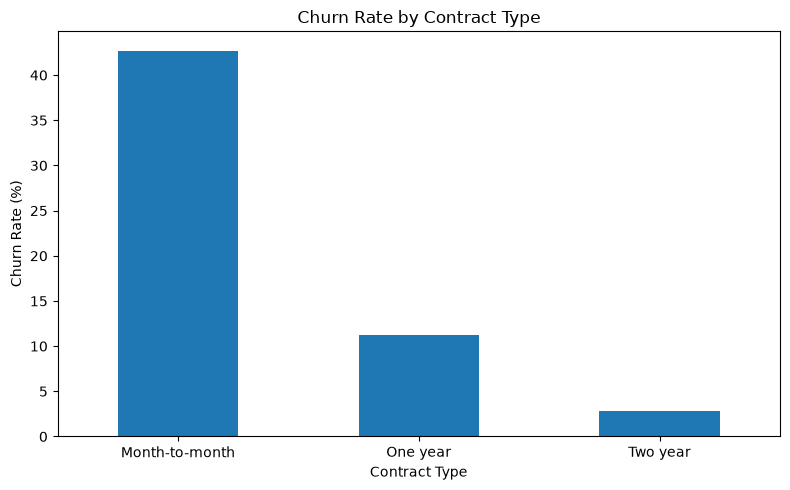

In [67]:
# Plot churn rate by contract type

plt.figure(figsize=(8, 5))

contract_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Month-to-month contract customers have the highest churn rate at 42.71%, followed by one-year contract customers at 11.27%. Two-year contract customers have the lowest churn rate at 2.83%. The substantial difference across contract types indicates that contract type is an important factor associated with customer churn.

In [68]:
# Calculate churn rate by internet service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [69]:
# Extract churn percentage for each internet service

internet_churn_rate = internet_churn["Yes"].sort_values(ascending=False)

internet_churn_rate

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

### 4.2 Churn Rate by Internet Service

The churn rate is compared across internet service types to identify customer segments with higher churn.

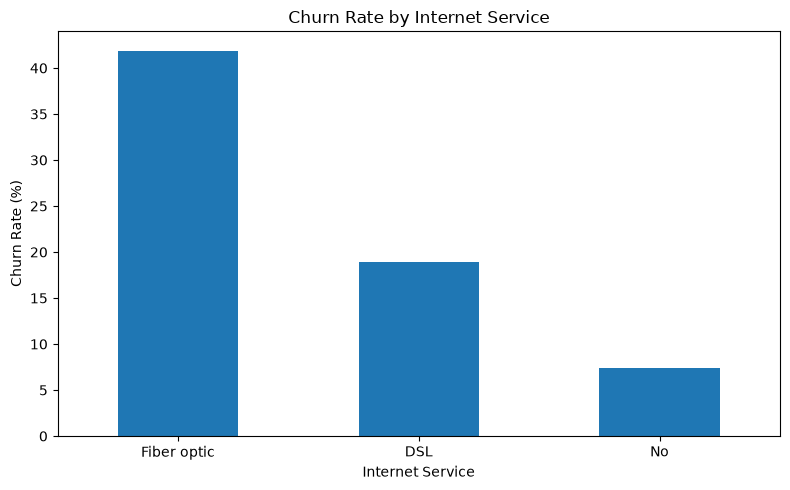

In [70]:
# Plot churn rate by internet service

plt.figure(figsize=(8, 5))

internet_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Finding

Fiber optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. The substantial difference in churn rates indicates that Internet Service is an important customer segment for further churn analysis.

In [71]:
# Calculate churn rate by payment method

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [72]:
# Extract churn percentage for each payment method

payment_churn_rate = payment_churn["Yes"].sort_values(ascending=False)

payment_churn_rate

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Yes, dtype: float64

### Finding

Electronic check customers have the highest churn rate at 45.29%, followed by mailed check customers at 19.11%. Customers using automatic bank transfer and automatic credit card payments have lower churn rates of 16.71% and 15.24%, respectively. This indicates that payment method is an important customer segment for further churn analysis.

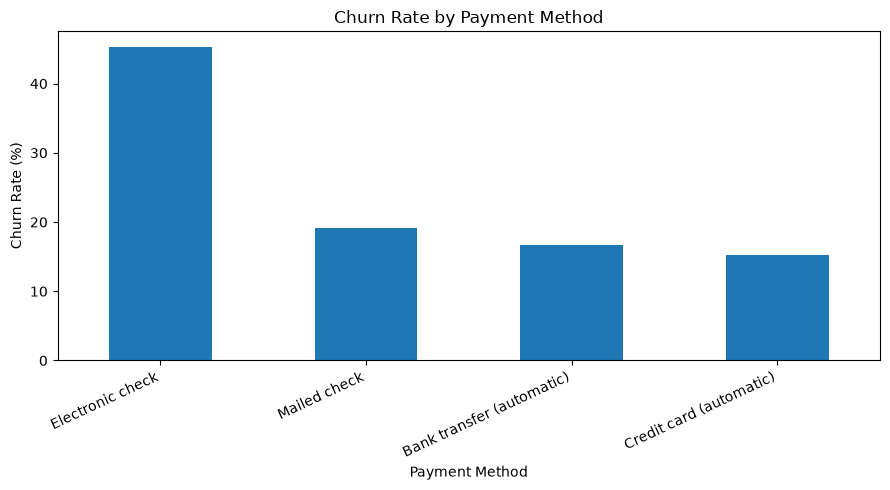

In [73]:
# Plot churn rate by payment method

plt.figure(figsize=(9, 5))

payment_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 5. Churn Rate by Tenure Group

Customers are grouped into tenure ranges to examine how churn behavior changes with the length of their relationship with the company.

In [74]:
# Create customer tenure groups

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["TenureGroup"].value_counts().sort_index()

TenureGroup
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [75]:
# Calculate churn rate by tenure group

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


In [76]:
# Extract churn percentage for each tenure group

tenure_churn_rate = tenure_churn["Yes"]

tenure_churn_rate

TenureGroup
0-12 months     47.438243
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: Yes, dtype: float64

### Finding

Churn rate decreases substantially as customer tenure increases. Customers with 0–12 months of tenure have the highest churn rate at 47.44%, while customers with 49–72 months of tenure have the lowest churn rate at 9.51%. The results indicate that newer customers are considerably more likely to churn than long-term customers, making tenure an important variable for churn analysis and prediction.

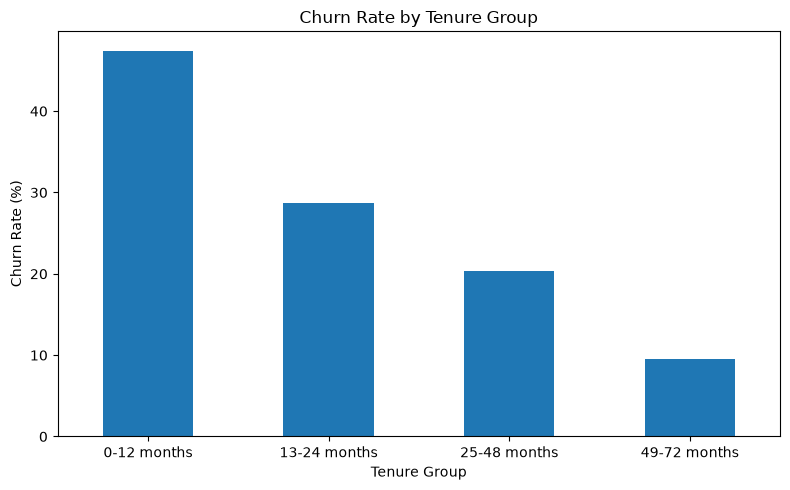

In [77]:
# Plot churn rate by tenure group

plt.figure(figsize=(8, 5))

tenure_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Churn Rate by Monthly Charges

Customers are grouped by monthly charge ranges to examine whether churn behavior differs across different billing levels.

In [78]:
# Create monthly charge groups

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, float("inf")],
    labels=["Low (18-40)", "Medium (40-70)", "High (70-100)", "Very High (100+)"]
)

df["MonthlyChargeGroup"].value_counts().sort_index()

MonthlyChargeGroup
Low (18-40)         1838
Medium (40-70)      1622
High (70-100)       2681
Very High (100+)     902
Name: count, dtype: int64

In [79]:
# Calculate churn rate by monthly charge group

monthly_charge_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

monthly_charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low (18-40),88.356910,11.643090
Medium (40-70),76.078915,23.921085
High (70-100),62.178292,37.821708
Very High (100+),71.951220,28.048780


In [80]:
# Extract churn percentage for each monthly charge group

monthly_charge_churn_rate = monthly_charge_churn["Yes"]

monthly_charge_churn_rate

MonthlyChargeGroup
Low (18-40)         11.643090
Medium (40-70)      23.921085
High (70-100)       37.821708
Very High (100+)    28.048780
Name: Yes, dtype: float64

### Finding

Churn rate generally increases with monthly charges up to the High (70-100) group. Customers in the High (70-100) group have the highest churn rate at 37.82%, while customers in the Low (18-40) group have the lowest churn rate at 11.64%. The Very High (100+) group has a lower churn rate of 28.05%, indicating that the relationship between monthly charges and churn is not completely linear.

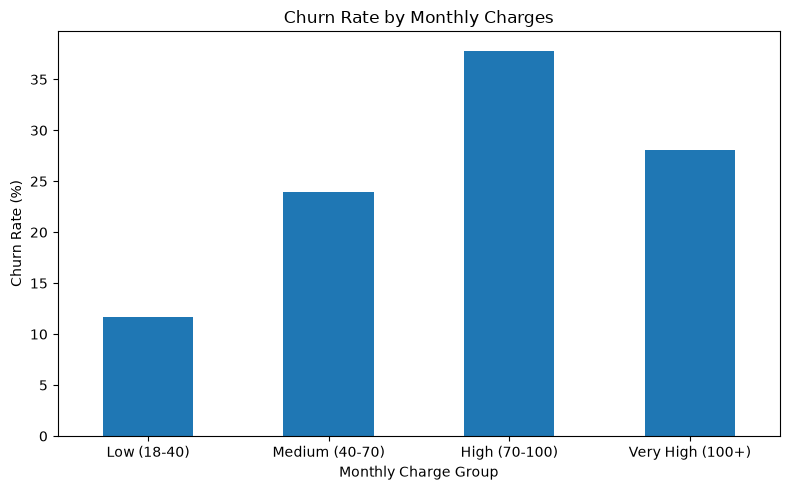

In [81]:
# Plot churn rate by monthly charge group

plt.figure(figsize=(8, 5))

monthly_charge_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Monthly Charges")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Day 3 Key Findings

The detailed customer segment analysis identified several important churn patterns:

- **Contract Type:** Month-to-month customers have the highest churn rate at 42.71%, while two-year contract customers have the lowest at 2.83%.

- **Internet Service:** Fiber optic customers have the highest churn rate at 41.89%, compared with 18.96% for DSL and 7.40% for customers without internet service.

- **Payment Method:** Electronic check customers have the highest churn rate at 45.29%, while automatic credit card payments have the lowest at 15.24%.

- **Tenure:** Churn decreases substantially as customer tenure increases. Customers with 0–12 months of tenure have a 47.44% churn rate, compared with 9.51% for customers with 49–72 months of tenure.

- **Monthly Charges:** Churn generally increases with monthly charges up to the 70–100 range. This group has the highest churn rate at 37.82%, while the 18–40 group has the lowest at 11.64%.

### Overall Observation

The analysis indicates that customer churn is particularly high among newer customers, month-to-month contract customers, fiber optic customers, electronic check users, and customers with higher monthly charges. These segments should receive further investigation during the next stages of the project.

## 8. Day 3 Conclusion

The detailed exploratory analysis identified several customer segments with noticeably different churn rates. Higher churn was observed among month-to-month contract customers, fiber optic customers, electronic check users, newer customers, and customers with higher monthly charges.

Tenure showed a particularly clear pattern, with churn decreasing as customer tenure increased. These findings provide useful direction for further analysis and will help identify important variables for the later churn prediction stage.

The analysis is exploratory and identifies associations between customer characteristics and churn; it does not establish causation.

# Customer Churn Prediction & LTV Engine

## Day 4 — Relationship Analysis & Feature Understanding

### Objectives

- Analyze the relationship between customer characteristics and churn.
- Compare churn rates across additional customer segments.
- Identify variables that may be useful for later churn prediction.
- Document important observations from the analysis.

## 1. Churn Rate by Senior Citizen Status

The churn rate is compared between senior and non-senior customers to determine whether customer age category is associated with churn.

In [82]:
# Calculate churn rate by senior citizen status

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [83]:
# Extract churn percentage for each senior citizen group

senior_churn_rate = senior_churn["Yes"]

senior_churn_rate

SeniorCitizen
0    23.606168
1    41.681261
Name: Yes, dtype: float64

### Finding

Senior customers have a churn rate of 41.68%, compared with 23.61% for non-senior customers. The higher churn rate among senior customers indicates that SeniorCitizen status is associated with different churn behavior and may be useful for further churn analysis.

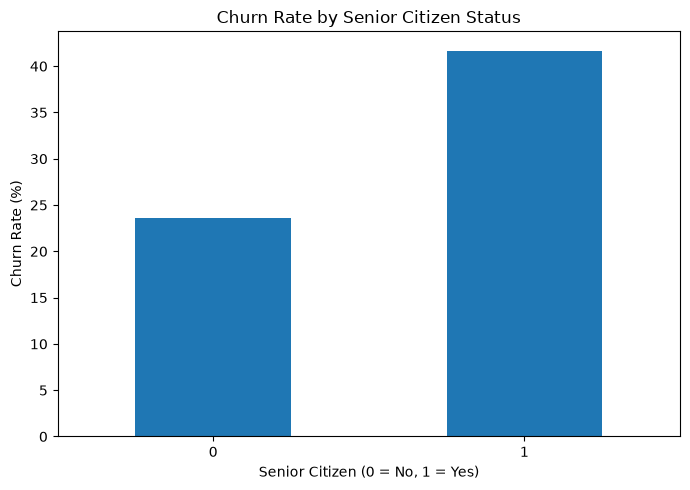

In [84]:
# Plot churn rate by senior citizen status

plt.figure(figsize=(7, 5))

senior_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Churn Rate by Partner Status

The churn rate is compared between customers with and without a partner to identify differences in churn behavior.

In [85]:
# Calculate churn rate by partner status

partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


In [86]:
# Extract churn percentage for each partner group

partner_churn_rate = partner_churn["Yes"]

partner_churn_rate

Partner
No     32.957979
Yes    19.664903
Name: Yes, dtype: float64

### Finding

Customers without a partner have a churn rate of 32.96%, compared with 19.66% for customers with a partner. The higher churn rate among customers without a partner indicates that Partner status is associated with differences in customer churn behavior.

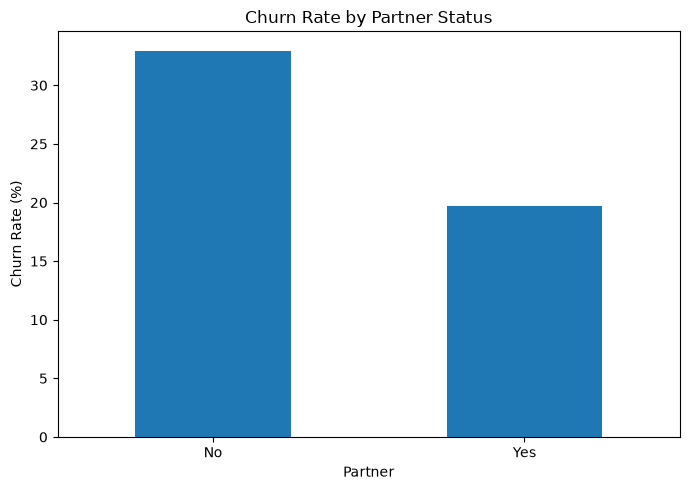

In [87]:
# Plot churn rate by partner status

plt.figure(figsize=(7, 5))

partner_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Churn Rate by Dependents

The churn rate is compared between customers with and without dependents to identify differences in churn behavior.

In [88]:
# Calculate churn rate by dependents status

dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


In [89]:
# Extract churn percentage for each dependents group

dependents_churn_rate = dependents_churn["Yes"]

dependents_churn_rate

Dependents
No     31.279140
Yes    15.450237
Name: Yes, dtype: float64

### Finding

Customers without dependents have a churn rate of 31.28%, compared with 15.45% for customers with dependents. The higher churn rate among customers without dependents indicates that Dependents status is associated with differences in customer churn behavior.

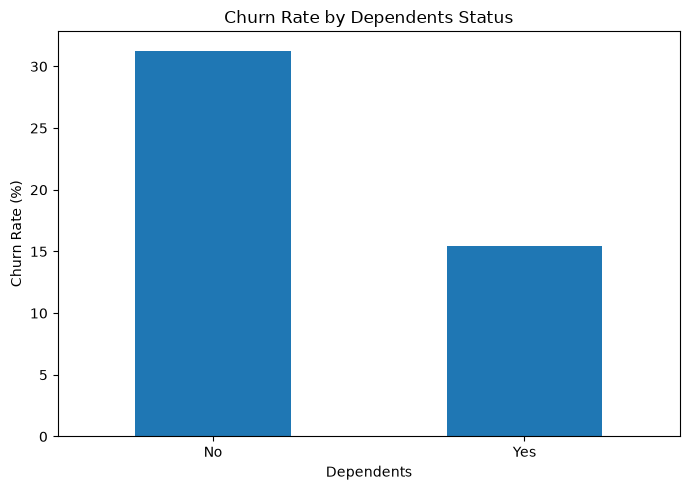

In [90]:
# Plot churn rate by dependents status

plt.figure(figsize=(7, 5))

dependents_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Dependents Status")
plt.xlabel("Dependents")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Churn Rate by Phone Service

The churn rate is compared between customers with and without phone service to identify differences in churn behavior.

In [91]:
# Calculate churn rate by phone service

phone_churn = pd.crosstab(
    df["PhoneService"],
    df["Churn"],
    normalize="index"
) * 100

phone_churn

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [92]:
# Extract churn percentage for each phone service group

phone_churn_rate = phone_churn["Yes"]

phone_churn_rate

PhoneService
No     24.926686
Yes    26.709637
Name: Yes, dtype: float64

### Finding

Customers with phone service have a churn rate of 26.71%, compared with 24.93% for customers without phone service. The difference is relatively small, indicating that PhoneService shows only a limited difference in churn rates in this dataset.

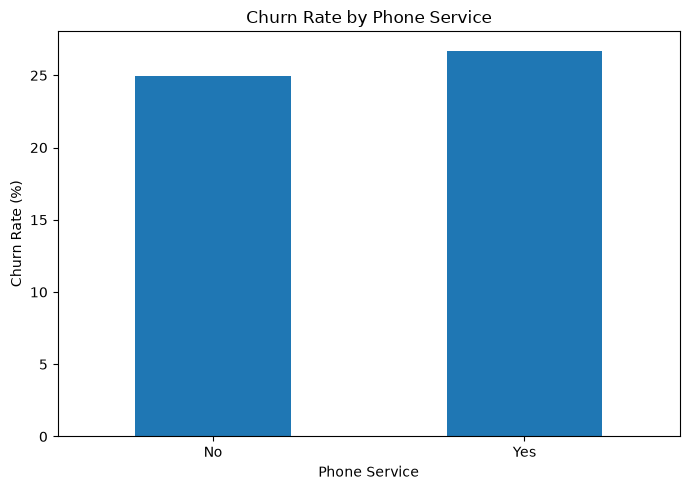

In [93]:
# Plot churn rate by phone service

plt.figure(figsize=(7, 5))

phone_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Churn Rate by Paperless Billing

The churn rate is compared between customers using paperless billing and those using non-paperless billing to identify differences in churn behavior.

In [94]:
# Calculate churn rate by paperless billing

paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [95]:
# Extract churn percentage for each paperless billing group

paperless_churn_rate = paperless_churn["Yes"]

paperless_churn_rate

PaperlessBilling
No     16.330084
Yes    33.565092
Name: Yes, dtype: float64

### Finding

Customers using paperless billing have a churn rate of 33.57%, compared with 16.33% for customers not using paperless billing. The noticeable difference indicates that PaperlessBilling is associated with different churn behavior in this dataset.

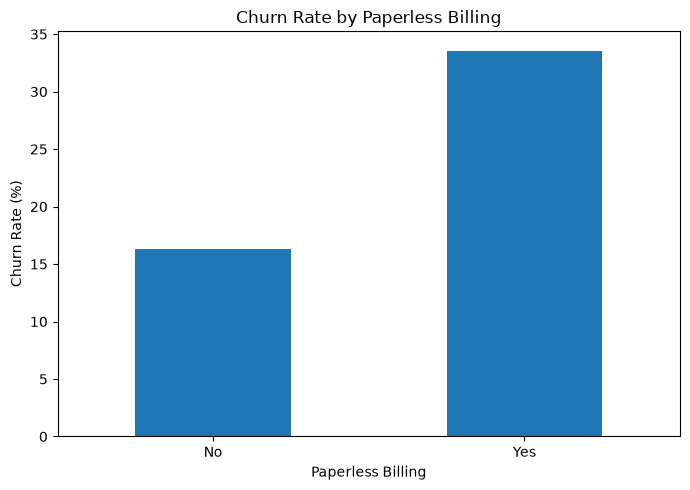

In [96]:
# Plot churn rate by paperless billing

plt.figure(figsize=(7, 5))

paperless_churn_rate.plot(kind="bar")

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Day 4 Key Findings

The relationship analysis identified several differences in churn rates across customer characteristics:

- **Senior Citizen:** Senior customers have a higher churn rate of 41.68% compared with 23.61% for non-senior customers.

- **Partner:** Customers without a partner have a higher churn rate of 32.96% compared with 19.66% for customers with a partner.

- **Dependents:** Customers without dependents have a higher churn rate of 31.28% compared with 15.45% for customers with dependents.

- **Phone Service:** Churn rates are relatively similar for customers with and without phone service, at 26.71% and 24.93% respectively.

- **Paperless Billing:** Customers using paperless billing have a higher churn rate of 33.57% compared with 16.33% for customers not using paperless billing.

### Overall Observation

Senior Citizen status, Partner status, Dependents status, and Paperless Billing show noticeable differences in churn rates, while Phone Service shows only a small difference. These variables can be considered for further analysis and later churn prediction.

These observations describe associations in the dataset and do not establish causation.

## 7. Day 4 Conclusion

The relationship analysis showed that several customer characteristics are associated with different churn rates. Senior Citizen, Partner, Dependents, and Paperless Billing showed noticeable differences in churn behavior, while Phone Service showed only a small difference.

These findings help identify customer characteristics that may be useful for further churn analysis and the later prediction stage.

The analysis identifies associations in the dataset and does not establish causation.

# Day 5 — Service-Level Churn Analysis

This analysis examines customer churn across different service-related features. The objective is to identify service categories that show noticeable differences in churn rates and may be useful for further churn analysis and prediction.

## 1. Churn Rate by Internet Service

The churn rate is compared across different internet service types to identify differences in customer churn behavior.

In [5]:
# Calculate churn rate by internet service

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [6]:
# Extract churn percentage for each internet service

internet_churn_rate = internet_churn["Yes"]

internet_churn_rate.sort_values(ascending=False)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Yes, dtype: float64

### Finding

Customers using fiber optic internet have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across internet service types.

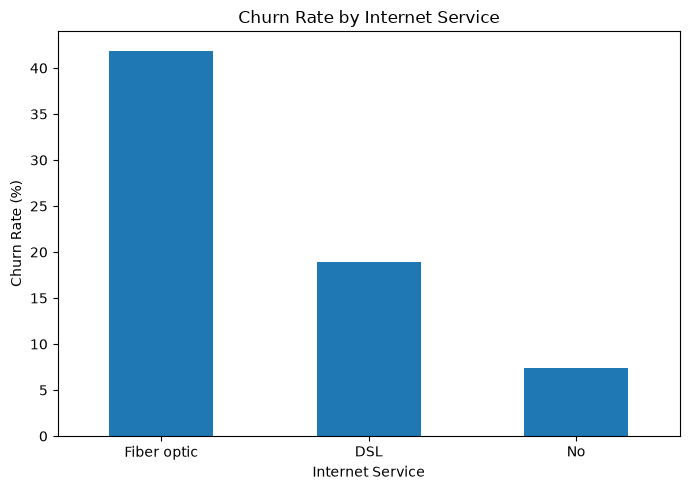

In [7]:
# Plot churn rate by internet service

plt.figure(figsize=(7, 5))

internet_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Churn Rate by Online Security

The churn rate is compared between customers with and without online security to identify differences in churn behavior.

In [8]:
# Calculate churn rate by online security

online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
) * 100

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


In [9]:
# Extract churn percentage for each online security group

online_security_churn_rate = online_security_churn["Yes"]

online_security_churn_rate.sort_values(ascending=False)

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without online security have the highest churn rate at 41.77%, compared with 14.61% for customers with online security. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across online security categories.

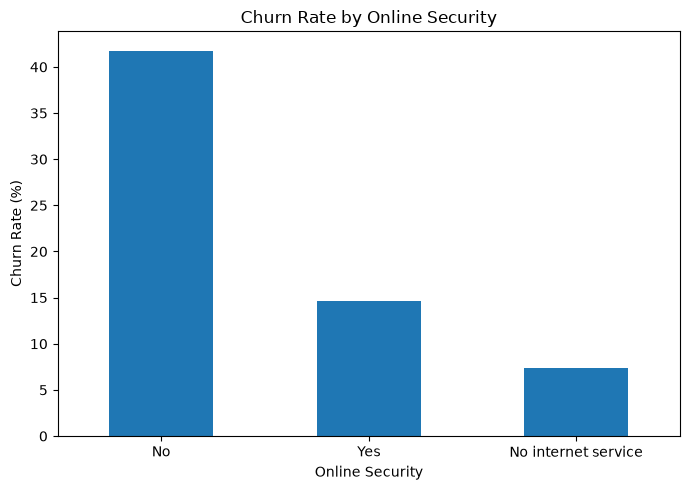

In [10]:
# Plot churn rate by online security

plt.figure(figsize=(7, 5))

online_security_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 3. Churn Rate by Online Backup

The churn rate is compared between customers with and without online backup to identify differences in churn behavior.

In [11]:
# Calculate churn rate by online backup

online_backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

online_backup_churn

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


In [12]:
# Extract churn percentage for each online backup group

online_backup_churn_rate = online_backup_churn["Yes"]

online_backup_churn_rate.sort_values(ascending=False)

OnlineBackup
No                     39.928756
Yes                    21.531494
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without online backup have the highest churn rate at 39.93%, compared with 21.53% for customers with online backup. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across online backup categories.

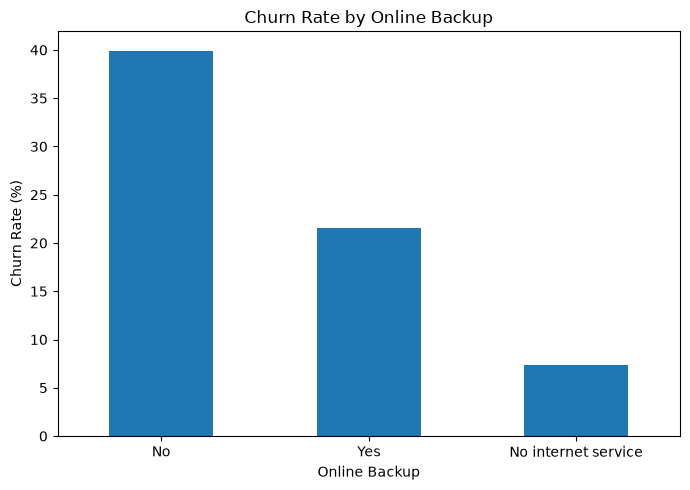

In [13]:
# Plot churn rate by online backup

plt.figure(figsize=(7, 5))

online_backup_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 4. Churn Rate by Device Protection

The churn rate is compared between customers with and without device protection to identify differences in churn behavior.

In [14]:
# Calculate churn rate by device protection

device_protection_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_protection_churn

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


In [15]:
# Extract churn percentage for each device protection group

device_protection_churn_rate = device_protection_churn["Yes"]

device_protection_churn_rate.sort_values(ascending=False)

DeviceProtection
No                     39.127625
Yes                    22.502064
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without device protection have the highest churn rate at 39.13%, compared with 22.50% for customers with device protection. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across device protection categories.

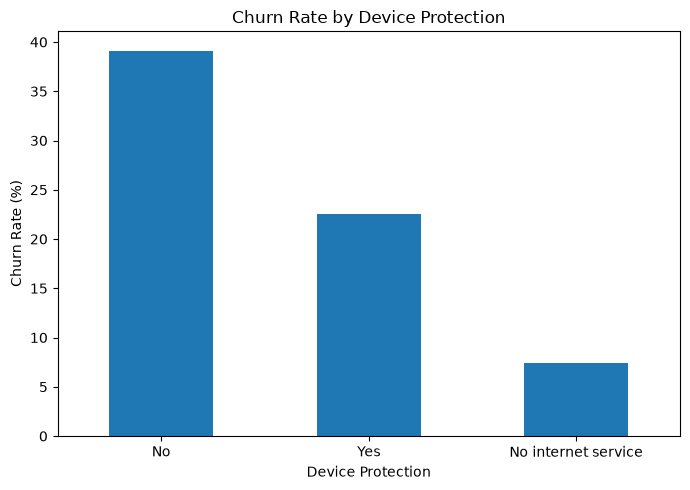

In [16]:
# Plot churn rate by device protection

plt.figure(figsize=(7, 5))

device_protection_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Churn Rate by Tech Support

The churn rate is compared between customers with and without technical support to identify differences in churn behavior.

In [17]:
# Calculate churn rate by tech support

tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [18]:
# Extract churn percentage for each tech support group

tech_support_churn_rate = tech_support_churn["Yes"]

tech_support_churn_rate.sort_values(ascending=False)

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without tech support have the highest churn rate at 41.64%, compared with 15.17% for customers with tech support. Customers without internet service have the lowest churn rate at 7.40%. This shows a noticeable difference in churn rates across tech support categories.

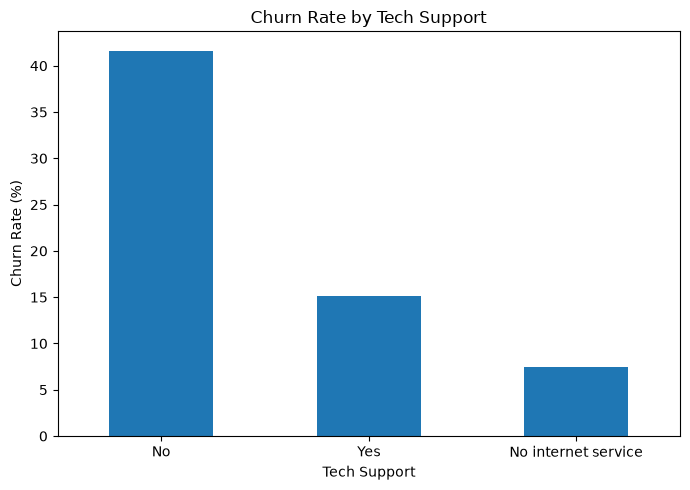

In [19]:
# Plot churn rate by tech support

plt.figure(figsize=(7, 5))

tech_support_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Churn Rate by Streaming TV

The churn rate is compared between customers with and without streaming TV to identify differences in churn behavior.

In [20]:
# Calculate churn rate by streaming TV

streaming_tv_churn = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

streaming_tv_churn

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [21]:
# Extract churn percentage for each streaming TV group

streaming_tv_churn_rate = streaming_tv_churn["Yes"]

streaming_tv_churn_rate.sort_values(ascending=False)

StreamingTV
No                     33.523132
Yes                    30.070188
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without streaming TV have a churn rate of 33.52%, compared with 30.07% for customers with streaming TV. Customers without internet service have the lowest churn rate at 7.40%. The difference between customers with and without streaming TV is relatively small.

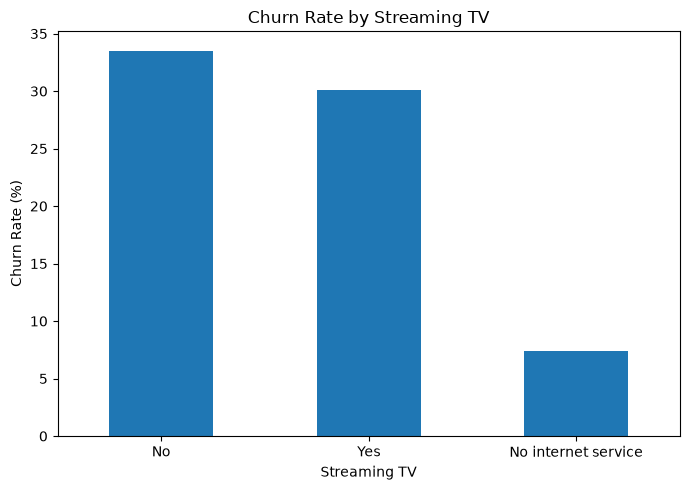

In [22]:
# Plot churn rate by streaming TV

plt.figure(figsize=(7, 5))

streaming_tv_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Churn Rate by Streaming Movies

The churn rate is compared between customers with and without streaming movies to identify differences in churn behavior.

In [23]:
# Calculate churn rate by streaming movies

streaming_movies_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

streaming_movies_churn

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


In [24]:
# Extract churn percentage for each streaming movies group

streaming_movies_churn_rate = streaming_movies_churn["Yes"]

streaming_movies_churn_rate.sort_values(ascending=False)

StreamingMovies
No                     33.680431
Yes                    29.941435
No internet service     7.404980
Name: Yes, dtype: float64

### Finding

Customers without streaming movies have a churn rate of 33.68%, compared with 29.94% for customers with streaming movies. Customers without internet service have the lowest churn rate at 7.40%. The difference between customers with and without streaming movies is relatively small.

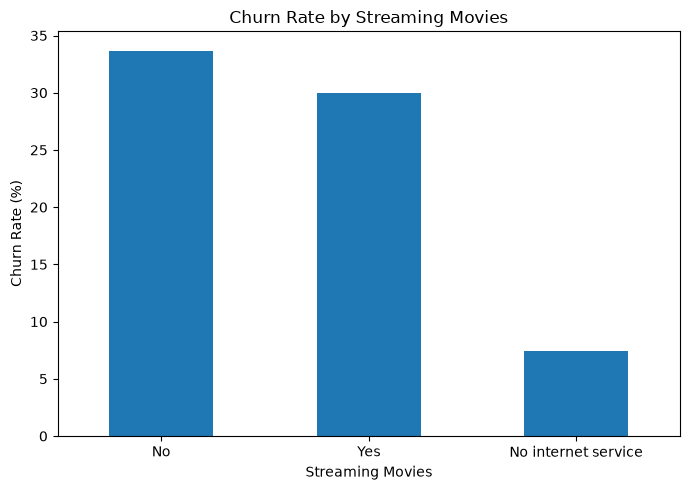

In [25]:
# Plot churn rate by streaming movies

plt.figure(figsize=(7, 5))

streaming_movies_churn_rate.sort_values(ascending=False).plot(kind="bar")

plt.title("Churn Rate by Streaming Movies")
plt.xlabel("Streaming Movies")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Day 5 Key Findings

The service-level analysis identified several noticeable differences in customer churn rates:

- **Internet Service:** Fiber optic customers have the highest churn rate at 41.89%, while customers without internet service have the lowest rate at 7.40%.

- **Online Security:** Customers without online security have a churn rate of 41.77%, compared with 14.61% for customers with online security.

- **Online Backup:** Customers without online backup have a churn rate of 39.93%, compared with 21.53% for customers with online backup.

- **Device Protection:** Customers without device protection have a churn rate of 39.13%, compared with 22.50% for customers with device protection.

- **Tech Support:** Customers without tech support have a churn rate of 41.64%, compared with 15.17% for customers with tech support.

- **Streaming TV:** Customers without streaming TV have a churn rate of 33.52%, compared with 30.07% for customers with streaming TV.

- **Streaming Movies:** Customers without streaming movies have a churn rate of 33.68%, compared with 29.94% for customers with streaming movies.

### Overall Observation

The largest differences in churn rates are observed for Internet Service, Online Security, Online Backup, Device Protection, and Tech Support. Customers lacking these additional services generally show higher churn rates. Streaming TV and Streaming Movies show smaller differences between customers with and without the services.

These findings describe associations in the dataset and do not establish causation.

## 9. Day 5 Conclusion

The service-level analysis showed that several additional services are associated with noticeable differences in customer churn rates. Internet Service, Online Security, Online Backup, Device Protection, and Tech Support showed particularly large differences between customer groups.

Customers without these additional services generally showed higher churn rates, while Streaming TV and Streaming Movies showed relatively smaller differences.

These findings provide useful features for further analysis and can help guide the later customer churn prediction stage.

The analysis identifies associations in the dataset and does not establish causation.